In [1]:
from EncoderDecoder.utils import loadData
import matplotlib.pyplot as plt
import scipy.io
import logging
import pandas as pd
import numpy as np
import re
logging.disable(logging.CRITICAL)

In [2]:
import os

#add the root directory
os.chdir('../')

## Transform dataset received from Malik to correct format for training of encoder-decoder

In [3]:
path = "data-files/extraData/2022-Malik-LES-for-PCA/"
name = "species&prod_rates_mass_T_rho_fromCFLF_f05_forPCA.mat"

#### Load file

In [4]:
file_path = os.path.join(path, name)

matFile = scipy.io.loadmat(file_path)

print(matFile.keys())

dict_keys(['__header__', '__version__', '__globals__', 'T', 'prod_rates', 'rho', 'species_mass', 'species_names'])


#### Check basic information

In [5]:
print(f'Header: {matFile["__header__"]}')
print(f'Version: {matFile["__version__"]}')
print(f'Globals: {matFile["__globals__"]}')
print(f'Number of species: {len(matFile["species_names"])}')

Header: b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Dec 23 21:30:32 2019'
Version: 1.0
Globals: []
Number of species: 35


#### Species names

In [6]:
print("Species names")
state_space_names_array = matFile["species_names"]
print(type(state_space_names_array))
print(state_space_names_array.shape)
state_space_names_array = [x[0] for x in state_space_names_array.flatten()]
print(state_space_names_array)

Species names
<class 'numpy.ndarray'>
(35, 1)
['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'C', 'CH', 'CH2', 'CH2S', 'CH3', 'CH4', 'CO', 'CO2', 'HCO', 'CH2O', 'CH2OH', 'CH3O', 'CH3OH', 'C2H', 'C2H2', 'C2H3', 'C2H4', 'C2H5', 'C2H6', 'HCCO', 'CH2CO', 'HCCOH', 'C3H7', 'C3H8', 'CH2CHO', 'CH3CHO', 'N2']


#### Create dataframes

In [7]:
data_state_space = pd.DataFrame(columns=state_space_names_array)
data_state_space_source = pd.DataFrame(columns=state_space_names_array)
data_mf = pd.DataFrame(columns=["f"])
data_T = pd.DataFrame(columns=["T"])

#### Temperature data

In [8]:
print("Temperature")
temp_array = matFile["T"]
print(type(temp_array))
print(temp_array.shape)
print(temp_array)
data_T = pd.DataFrame(temp_array, columns = ["T"])
print(data_T)

Temperature
<class 'numpy.ndarray'>
(89449, 1)
[[ 320.   ]
 [ 320.   ]
 [ 320.   ]
 ...
 [1355.001]
 [1355.001]
 [1355.   ]]
              T
0       320.000
1       320.000
2       320.000
3       320.000
4       320.000
...         ...
89444  1355.002
89445  1355.002
89446  1355.001
89447  1355.001
89448  1355.000

[89449 rows x 1 columns]


#### Species mass fractions data

In [9]:
print("Species mass fractions")
state_space_array = matFile["species_mass"]
print(type(state_space_array))
print(state_space_array.shape)
print(state_space_array)
data_state_space = pd.DataFrame(state_space_array, columns = state_space_names_array)
print(data_state_space)

Species mass fractions
<class 'numpy.ndarray'>
(89849, 35)
[[5.04269744e-09 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  6.94355593e-23 5.96100339e-01]
 [5.60134288e-09 2.55754737e-31 1.13224326e-49 ... 0.00000000e+00
  3.61595494e-23 5.96100339e-01]
 [6.22183280e-09 5.68830145e-35 1.56938953e-49 ... 0.00000000e+00
  1.12238154e-22 5.96100338e-01]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 7.56170172e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 7.56573346e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 7.56976520e-01]]
                 H2             H             O        O2            OH  \
0      5.042697e-09  0.000000e+00  0.000000e+00  0.188558  0.000000e+00   
1      5.601343e-09  2.557547e-31  1.132243e-49  0.188558  7.285347e-26   
2      6.221833e-09  5.688301e-35  1.569390e-49  0.188558  8.242601e-30   
3      6.911121e-09  8.499935e-37  2.1819

#### Reaction rates/source terms data

In [10]:
print("Species reaction rates")
state_space_source_array = matFile["prod_rates"]
print(type(state_space_source_array))
print(state_space_source_array.shape)
print(state_space_source_array)
data_state_space_source = pd.DataFrame(state_space_source_array, columns = state_space_names_array)
print(data_state_space_source)

Species reaction rates
<class 'numpy.ndarray'>
(89849, 35)
[[-2.35687459e-27  1.47142194e-27  7.64245940e-46 ...  0.00000000e+00
  -1.98441055e-41  0.00000000e+00]
 [-1.24008376e-28 -1.04696718e-24  2.68201621e-32 ...  2.96911854e-46
  -1.25069820e-39  0.00000000e+00]
 [-5.20823218e-31 -3.23760887e-28  5.96512918e-36 ...  2.04976228e-49
  -3.25123179e-41  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
                 H2             H             O            O2            OH  \
0     -2.356875e-27  1.471422e-27  7.642459e-46 -1.151117e-17  4.588383e-22   
1     -1.240084e-28 -1.046967e-24  2.682016e-32 -8.166908e-15 -6.430872e-21   
2     -5.208232e-31 -3.237609e-28  5.965129e-36 -2.584129e-19 -6.500

##### Compute mixture fraction and update data_T with extra simulation pure mixing: taking into account that the fuel side is mixed with oxygen

In [11]:
# Atomic weights
atomic_weights = {
    "C": 12.011,
    "H": 1.008,
    "O": 15.999,
    "N": 14.007,
    "S": 32.06,
}

def parse_species_formula(species):
    """
    Convert species name into elemental composition.
    Example:
        CH4 -> {'C':1, 'H':4}
        CH3OH -> {'C':1, 'H':4, 'O':1}
        O2 -> {'O':2}
    """
    elements = re.findall(r"([A-Z][a-z]?)(\d*)", species)

    composition = {}
    for element, number in elements:
        composition[element] = int(number) if number else 1

    return composition


def compute_element_mass_fraction(data_state_space, species_names, element):
    """
    Compute elemental mass fraction Z_element from species mass fractions.
    """

    Z_element = np.zeros(len(data_state_space))

    for species in species_names:
        composition = parse_species_formula(species)

        if element not in composition:
            continue

        MW_species = sum(
            atomic_weights[e] * n
            for e, n in composition.items()
        )

        Z_element += (
            data_state_space[species]
            * composition[element]
            * atomic_weights[element]
            / MW_species
        )

    return Z_element

def compute_beta(data_state_space, species_names):
    """
    Compute Bilger beta from species mass fractions.
    """

    Z_C = compute_element_mass_fraction(
        data_state_space,
        species_names,
        "C"
    )

    Z_H = compute_element_mass_fraction(
        data_state_space,
        species_names,
        "H"
    )

    Z_O = compute_element_mass_fraction(
        data_state_space,
        species_names,
        "O"
    )

    beta = (
        2 * Z_C / atomic_weights["C"]
        + 0.5 * Z_H / atomic_weights["H"]
        - Z_O / atomic_weights["O"]
    )

    return beta

##### Fourth method v2: compute for every simulation

###### Detect jumps and group by simulation

In [12]:
# CH4 profile
Y_CH4 = data_state_space["CH4"].values

# Compute jumps in CH4
dCH4 = np.diff(Y_CH4)

# Threshold for detecting new simulations
# Adapt this depending on your dataset
threshold = 0.1

# Indices where a new simulation starts
simulation_starts = np.where(dCH4 > threshold)[0] + 1

# Add first simulation start
simulation_starts = np.insert(simulation_starts, 0, 0)

print("Detected simulation starts:")
print(simulation_starts)
print("Number of simulations:", len(simulation_starts))

Detected simulation starts:
[    0   401   802  1203  1604  2005  2406  2807  3208  3609  4010  4411
  4812  5213  5614  6015  6416  6817  7218  7619  8020  8421  8822  9223
  9624 10025 10426 10827 11228 11629 12030 12431 12832 13233 13634 14035
 14436 14837 15238 15639 16040 16441 16842 17243 17644 18045 18446 18847
 19248 19649 20050 20451 20852 21253 21654 22055 22456 22857 23258 23659
 24060 24461 24862 25263 25664 26065 26466 26867 27268 27669 28070 28471
 28872 29273 29674 30075 30476 30877 31278 31679 32080 32481 32882 33283
 33684 34085 34486 34887 35288 35689 36090 36491 36892 37293 37694 38095
 38496 38897 39298 39699 40100 40501 40902 41303 41704 42105 42506 42907
 43308 43709 44110 44511 44912 45313 45714 46115 46516 46917 47318 47719
 48120 48521 48922 49323 49724 50125 50526 50927 51328 51729 52130 52531
 52932 53333 53734 54135 54536 54937 55338 55739 56140 56541 56942 57343
 57744 58145 58546 58947 59348 59749 60150 60551 60952 61353 61758 62163
 62568 62973 63378 6378

#### Add missing data to temperature array

T    320.0
Name: 89024, dtype: float64
T    1355.0
Name: 89448, dtype: float64


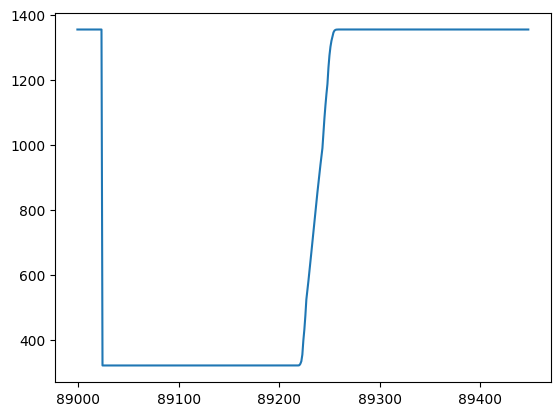

[[ 320.        ]
 [ 322.59398496]
 [ 325.18796992]
 [ 327.78195489]
 [ 330.37593985]
 [ 332.96992481]
 [ 335.56390977]
 [ 338.15789474]
 [ 340.7518797 ]
 [ 343.34586466]
 [ 345.93984962]
 [ 348.53383459]
 [ 351.12781955]
 [ 353.72180451]
 [ 356.31578947]
 [ 358.90977444]
 [ 361.5037594 ]
 [ 364.09774436]
 [ 366.69172932]
 [ 369.28571429]
 [ 371.87969925]
 [ 374.47368421]
 [ 377.06766917]
 [ 379.66165414]
 [ 382.2556391 ]
 [ 384.84962406]
 [ 387.44360902]
 [ 390.03759398]
 [ 392.63157895]
 [ 395.22556391]
 [ 397.81954887]
 [ 400.41353383]
 [ 403.0075188 ]
 [ 405.60150376]
 [ 408.19548872]
 [ 410.78947368]
 [ 413.38345865]
 [ 415.97744361]
 [ 418.57142857]
 [ 421.16541353]
 [ 423.7593985 ]
 [ 426.35338346]
 [ 428.94736842]
 [ 431.54135338]
 [ 434.13533835]
 [ 436.72932331]
 [ 439.32330827]
 [ 441.91729323]
 [ 444.5112782 ]
 [ 447.10526316]
 [ 449.69924812]
 [ 452.29323308]
 [ 454.88721805]
 [ 457.48120301]
 [ 460.07518797]
 [ 462.66917293]
 [ 465.26315789]
 [ 467.85714286]
 [ 470.4511278

In [13]:
data_T_fuel = data_T.iloc[simulation_starts[-2]]
data_T_oxidizer = data_T.iloc[-1]
print(data_T_fuel)
print(data_T_oxidizer)

plt.plot(data_T[-450:])
plt.show()

extraSimT = np.linspace(data_T_fuel, data_T_oxidizer, 400)
print(extraSimT)

extra_df = pd.DataFrame(extraSimT, columns=data_T.columns)

data_T = pd.concat([data_T, extra_df], ignore_index=True)

In [14]:
simulation_id = np.zeros(len(data_state_space), dtype=int)

for i, start in enumerate(simulation_starts):
    if i < len(simulation_starts)-1:
        simulation_id[start:simulation_starts[i+1]] = i
    else:
        simulation_id[start:] = i

# Add to dataframe
data_state_space["simulation_id"] = simulation_id

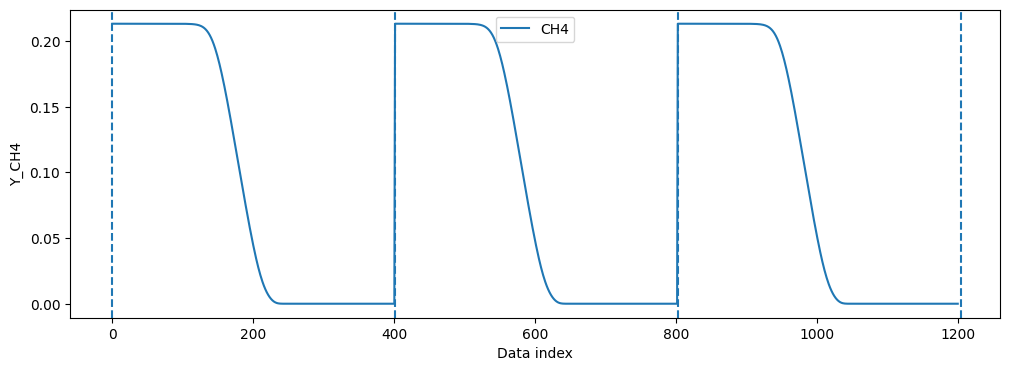

In [15]:
plt.figure(figsize=(12,4))

plt.plot(Y_CH4[:1200], label="CH4")

for start in simulation_starts[:4]:
    plt.axvline(start, linestyle="--")

plt.xlabel("Data index")
plt.ylabel("Y_CH4")
plt.legend()
plt.show()

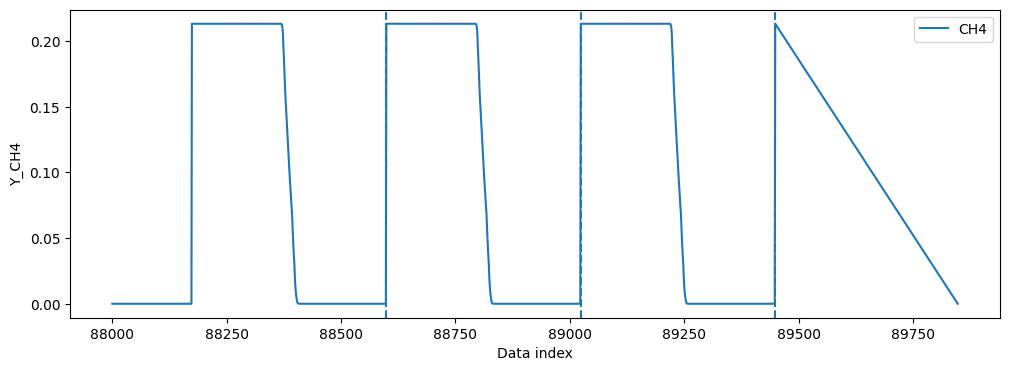

In [16]:
plt.figure(figsize=(12,4))

plt.plot(np.arange(88000,len(Y_CH4)),Y_CH4[88000:], label="CH4")

for start in simulation_starts[-3:]:
    plt.axvline(start, linestyle="--")

plt.xlabel("Data index")
plt.ylabel("Y_CH4")
plt.legend()
plt.show()

Points on begin and end of simulations are correctly assigned

In [17]:
for sim_id, simulation in data_state_space.groupby("simulation_id"):

    beta = compute_beta(
        simulation,
        state_space_names_array
    )

    beta_fuel = compute_beta(
        simulation.iloc[0],
        state_space_names_array
    )[0]

    beta_oxidizer = compute_beta(
        simulation.iloc[simulation.shape[0]-1],
        state_space_names_array
    )[0]

    f = (beta - beta_oxidizer) / (beta_fuel - beta_oxidizer)

    data_state_space.loc[simulation.index, "f"] = f

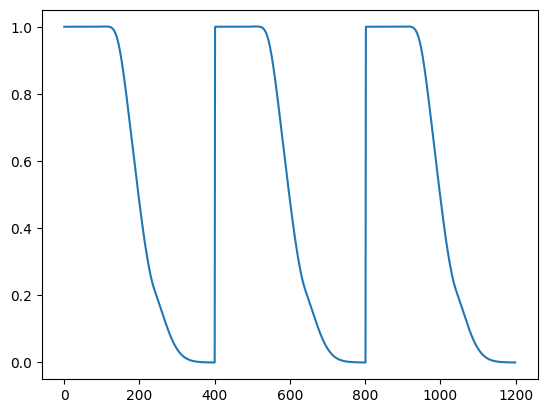

In [18]:
plt.plot(data_state_space["f"][0:1200])
plt.show()

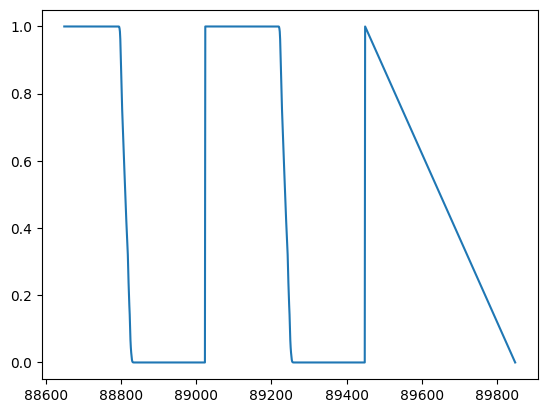

In [19]:
plt.plot(data_state_space["f"][-1200:])
plt.show()

In [20]:
data_mixture_fraction = data_state_space["f"]
data_mixture_fraction = pd.DataFrame(data_mixture_fraction, columns = ["f"])
print(data_mixture_fraction)
data_state_space = data_state_space.drop(columns = ["simulation_id", "f"])

              f
0      1.000000
1      1.000000
2      1.000000
3      1.000000
4      1.000000
...         ...
89844  0.010025
89845  0.007519
89846  0.005013
89847  0.002506
89848  0.000000

[89849 rows x 1 columns]


In [21]:
print(data_state_space)

                 H2             H             O        O2            OH  \
0      5.042697e-09  0.000000e+00  0.000000e+00  0.188558  0.000000e+00   
1      5.601343e-09  2.557547e-31  1.132243e-49  0.188558  7.285347e-26   
2      6.221833e-09  5.688301e-35  1.569390e-49  0.188558  8.242601e-30   
3      6.911121e-09  8.499935e-37  2.181901e-49  0.188558  9.327536e-34   
4      7.676732e-09  9.231679e-37  3.040092e-49  0.188558  3.814869e-37   
...             ...           ...           ...       ...           ...   
89844  0.000000e+00  0.000000e+00  0.000000e+00  0.142061  0.000000e+00   
89845  0.000000e+00  0.000000e+00  0.000000e+00  0.141943  0.000000e+00   
89846  0.000000e+00  0.000000e+00  0.000000e+00  0.141825  0.000000e+00   
89847  0.000000e+00  0.000000e+00  0.000000e+00  0.141708  0.000000e+00   
89848  0.000000e+00  0.000000e+00  0.000000e+00  0.141590  0.000000e+00   

            H2O           HO2          H2O2    C             CH  ...  \
0      0.002120  0.000000e+

#### Save data into csv files

In [22]:
data_state_space.to_csv('data-files/Malik-state-space-CFLF-2022.csv', index=False)
data_state_space_source.to_csv('data-files/Malik-state-space_source-CFLF-2022.csv', index=False)
data_T.to_csv('data-files/Malik-T-CFLF-2022.csv', index=False)
data_mixture_fraction.to_csv('data-files/Malik-mf-CFLF-2022.csv', index=False)

In [80]:
np.savetxt("data-files/Malik-state-space-names-CFLF-2022.csv",(state_space_names_array), delimiter=',', fmt='%s')